In [ ]:
# capstone project -- function 3 (3D), week N

import numpy as np
import matplotlib.pyplot as plt

# Delaunay: convex-hull membership check for the proposal.
# ConvexHull: hull volume, to quantify how loose the bounding box is.
from scipy.spatial import Delaunay, ConvexHull

from bayes_tools import (
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 3

3D, 18 observations (15 initial + weeks 2–4). **Acquisition is `ucb` with `kappa = 1.0`; bounds are the observed bounding box; the search is restricted to x2.**

Proposal this week: **`[0.492581, 0.611593, 0.867843]`** (GP mean −0.029, std 0.019, predicted improvement +0.0057) — a new best if it holds.

## Why only x2 is searched

ARD length-scales are `[10.0, 10.0, 0.131]`: x0 and x1 are pinned at the upper bound, so the GP sees signal only in **x2**. The acquisition is therefore flat along x0/x1 and its argmax on those axes is arbitrary — left free it parks them on a box edge outside the data cloud. So x0/x1 are held at the incumbent `[0.4926, 0.6116]` and only x2 is scanned.

Unlike previous weeks this is now backed by data, not just the GP. Over pairs of observations with similar x2 (|Δx2| ≤ 0.06), mean |Δy| is **0.0159** when x0/x1 are far apart (n=9) versus **0.0202** when they are close (n=5) — moving x0/x1 a long way changes `y` no more than staying put, against an overall `y` std of 0.0793. Weak (small n) but independent of the pinned length-scales, which is what mattered: the worry was that pinning might be self-reinforcing, since all three collected points sit on one x0/x1 line.

`pad_fraction=1.0` bounds stay rejected: the data covers only **10.2%** of that box by volume, which is mostly empty padding for the acquisition to wander into.

## Why the acquisition changed this week

Week 4 sampled x2=0.844 and returned **−0.0356** — second-best on record, and roughly **0.08 above both** its bracketing observations (−0.1180 and −0.1139). A sharp peak was hiding between two low samples, which is exactly what `max_variance` is for. It also refuted last week's note that agreeing brackets made the point a weak bet: agreement says nothing about the interior when the gap exceeds the length-scale.

That gap-to-length-scale ratio is the criterion, and it has now reversed:

| | largest x2 gap | x2 length-scale | ratio |
|---|---|---|---|
| week 4 | 0.149 | 0.110 | **1.35** → hid a peak |
| now | 0.109 | 0.121 | **0.90** |

Every remaining gap along x2 is smaller than the length-scale, so the GP can interpolate them, and `max_variance` would spend this week at x2=0.617 where it predicts −0.080 ± 0.031 — a region it is fairly confident is poor. Meanwhile the posterior mean now peaks *above* the incumbent at x2≈0.863. Hence `ucb`, `kappa=1.0`, which lands within 0.005 of pure `exploit` while keeping a variance term.

**`kappa = 1.0` is the last usable step, not a comfortable middle.** The sweep jumps mode between `kappa=1.0` (x2=0.868) and `kappa=1.5` (x2=0.511) — so the committed value sits directly against the mode switch, as function 1's `KAPPA=3.0` does. Re-check the sweep every week: functions 1, 2 and 4 all have discontinuities like this, none in the same place, and function 1's moved on a single observation.

**Two reasons this proposal is a modest bet.** It sits only **0.024** from the week-4 observation, against an x2 length-scale of 0.121 — about a fifth of a length-scale, so it is a local refinement rather than a new question. And it falls **outside the convex hull** of the observations (it passes the per-axis test, which box bounds guarantee, and fails the stronger one), because x2=0.868 is past the week-4 point at the edge of the sampled line. Last week's `max_variance` proposal was inside the hull; this one is not. That is the price of leaning toward exploitation at the edge of the data.

**The caveat worth holding.** Only four real evaluations have been spent, and the GP's smoothness assumption was already violated once — it thought a 0.149 gap was interpolable and it was not. "All gaps now below the length-scale" rests on a fitted length-scale that has proven optimistic, so if this week's exploit misses, treat that as evidence to go back to exploring rather than to exploit harder.

## Notes

- **The backtest ranks `max_variance` last** (0.126) and `ucb_k1` second (0.0371, effectively tied with `exploit` 0.0362). It has favoured exploitation all along — it scores recognition of already-known points — so its agreeing with this week's switch is weak corroboration, not the reason for it. See CLAUDE.md.
- **The diagnostics replay below deliberately still uses `max_variance`**, because all three collected points were proposed with it. From next week the history is mixed and the `acq_value` column cannot be faithful for every row.
- **No y-scaling.** `y` runs −0.399 to −0.035; `xi=0.01` is 2.75% of the spread.
- LOO calibration: 16/18 points inside their own 95% interval.
- `plot_2d_bo` doesn't apply at D=3 — the GP view is `plot_nd_slices`. `plot_bo_diagnostics`/`plot_sample_trajectory` hard-code a 2D panel and are skipped.


In [18]:
X_initial = np.load("initial_data/function_3/initial_inputs.npy")
y_initial = np.load("initial_data/function_3/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 3, f"Expected a 3D problem, got {D}D input -- check the loaded file."

# Once, at the very start of the capstone:
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week, oldest first -- row order must be true chronological order, or `compute_iteration_diagnostics` at the bottom is meaningless.

One observation is recorded so far. It predates the switch away from PI (the old version of this notebook proposed with `pi`/`xi=0.01`), so the history is mixed in terms of what chose each point. The diagnostics section explains how the replay handles that.

In [19]:
# Append last week's result BEFORE proposing this week's point, e.g.:
#
# new_X, new_y = append_observations(new_X, new_y, x_next, the_result_you_got)

new_X = np.array([
    [0.270875, 0.2582, 0.418474],       # week 2
    [0.492581, 0.611593, 0.669818],     # week 3 -- the max_variance proposal
    [0.492581, 0.611593, 0.843766],
])

new_y = np.array([
    -0.05641777085561445,
    -0.1100596532042417,
    -0.03556164746688873,
])

print("observations collected so far:", len(new_y))
print("latest y: %.6f | best before it: %.6f (change %+.6f)"
      % (new_y[-1], max(y_initial.max(), new_y[0]),
         new_y[-1] - max(y_initial.max(), new_y[0])))


observations collected so far: 3
latest y: -0.035562 | best before it: -0.034835 (change -0.000726)


## Build the full dataset (initial + everything collected so far)

In [ ]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("new_X shape:     ", new_X.shape, "| new_y shape:     ", new_y.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

# The project-standard bounds. X is known to never be negative, so
# lower_limit=0.0 is mandatory -- without it this function's padded bounds
# start at about -0.87 / -0.50 / -0.86, which are impossible inputs.
bounds_standard = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0,
                        upper_limit=1.0)
validate_bounds_consistency(X, bounds_standard)

# DELIBERATE DEVIATION THIS WEEK (see header): search only the axis-aligned
# bounding box of the observed data, so no coordinate can exceed the range
# already seen on its own axis. NOTE this is the bounding BOX, not the convex
# hull -- a corner of the box can still be far outside the data cloud, so this
# constrains extrapolation without eliminating it. The proposal cell checks
# convex-hull membership separately. Revert to bounds_standard once the GP has
# reason to prefer a direction along x0/x1, or the search can never expand
# beyond the initial batch's footprint.
bounds_box = np.column_stack([X.min(axis=0), X.max(axis=0)])
validate_bounds_consistency(X, bounds_box)

bounds = bounds_box

print("\nstandard bounds (pad_fraction=1.0):\n", np.round(bounds_standard, 4))
print("\nobserved bounding box (USED THIS WEEK):\n", np.round(bounds_box, 4))

print("\nfraction of each standard-bounds axis actually covered by data:")
frac = 1.0
for d in range(D):
    f = (X[:, d].max() - X[:, d].min()) / (bounds_standard[d, 1] - bounds_standard[d, 0])
    frac *= f
    print(f"  x{d}: {f:.1%}")
print(f"  -> {frac:.1%} of the standard box by volume; the rest is extrapolation")

# How loose is the bounding box as a stand-in for "where the data is"? In 3D
# with few points the cloud is nearly all surface, so the box overstates it.
hull = Delaunay(X)
box_volume = float(np.prod(bounds_box[:, 1] - bounds_box[:, 0]))
try:
    ch_volume = ConvexHull(X).volume
    print(f"\nbounding box volume: {box_volume:.5f} | true convex hull volume: {ch_volume:.5f}"
          f" ({ch_volume / box_volume:.1%} of the box)")
except Exception as exc:  # degenerate point set -- not fatal, just skip
    print("\nconvex hull volume unavailable:", exc)

xi_frac = 0.01 / (y.max() - y.min())
print(f"\nxi=0.01 is {xi_frac:.2%} of the y spread "
      f"-> {'scaling NOT needed' if 0.001 <= xi_frac <= 0.1 else 'CONSIDER y-scaling'}")

## Backtest acquisition functions (using only data already collected)

A weak, free check on acquisition family: repeatedly split the data into a "seed" set (fits the GP) and a held-out "candidate" set (true y known, hidden from the fit), then see which config would have picked the best candidate most often. No new evaluations spent.

**Expect `max_variance` to come last, and expect that not to matter.** The metric scores recognition of points whose true `y` is already known, which is an exploitation task -- it rewards whatever ranks closest to the GP posterior mean and gives no credit for reducing uncertainty. A pure uncertainty-seeker is therefore penalised by construction, so this table cannot be used to argue against this week's choice. See the header.

The ordering among the *other* configs is weak too: the top four sit within about 0.014 with near-identical median regret (PI and EI are separated by 0.00005), and on function 2 the leader changed when a single observation was added.

Note these numbers move with the bounds, since the bounds set the input normalisation the GP is fit on -- they'll differ from a week run on the standard padded bounds. Don't compare across bounds choices.

LIMITATION: this only tests recognition of good points *already in the dataset*. It cannot test which config is best at proposing a genuinely new location, since there's no ground truth for that without a real evaluation -- which is exactly the question that matters this week. Kept because it's cheap and becomes informative later, once there are more points and the goal shifts to drilling in.

[fitting: acquisition backtest, 50 splits] 107 warnings held back, 5 distinct:
    35 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    34 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    26 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
    11 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at lower bound 0.01
      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
     exploit |      0.03624 |        0.02158 |       -0.07343
      ucb_k1 |      0.03711 |        0.02139 |       -0.07431
    pi_xi001 |         0.05 |        0.03094 |       -0.08719
    ei_xi001 |      0.05037 |        0.03458 |       -0.08756
      ucb_k5 |       0.0628 |        0.04028 |       -0.09999
     max_var |       0.1262 |        0.07396 |        -0.1634

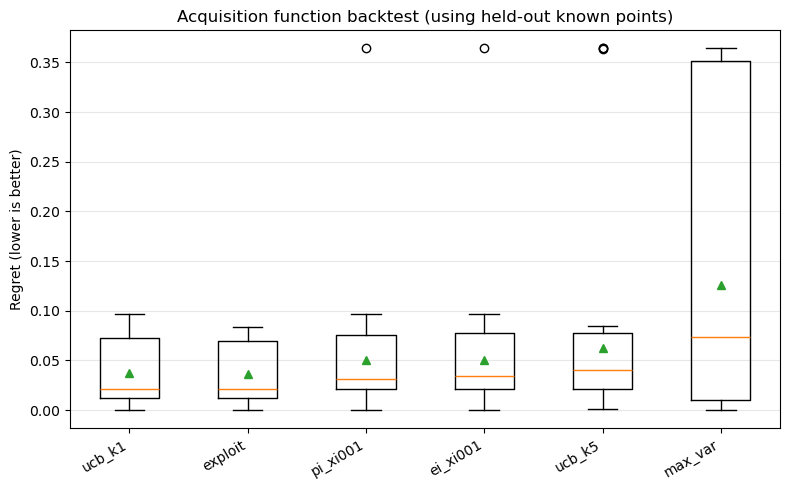

In [21]:
# xi/kappa are in raw y-units here (no y-scaling in this notebook -- see header).
backtest_configs = [
    {"name": "ei_xi001", "acquisition": "ei",  "xi": 0.01},
    {"name": "pi_xi001", "acquisition": "pi",  "xi": 0.01},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]

with fitting("acquisition backtest, 50 splits"):
    backtest_results = backtest_acquisitions(
        X, y, bounds, backtest_configs,
        n_repeats=50, seed_frac=0.5, maximize=True,
        gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
    )

print_backtest_summary(backtest_results)

plot_acquisition_backtest(backtest_results)
plt.show()

## Sensitivity check: which dimensions actually matter

Per-dimension ARD length-scales. Short = the function varies quickly along that axis, so it matters. Pinned at the upper `length_scale_bounds` = the GP sees that axis as close to irrelevant.

**Only "pinned vs. not pinned" is trustworthy** -- don't compare two dimensions that are both pinned. Expect x0 and x1 pinned at 10.0 and only x2 short (~0.104 under this week's box bounds; ~0.056 under the wider standard bounds, since the rescale compresses the data).

This cell is load-bearing for the whole approach: the proposal below restricts its search to whichever dimensions come back non-pinned, and warns if that stops being exactly one. It also explains why the `plot_nd_slices` panels for x0 and x1 look flat -- that's the model, not a plotting bug.

In [22]:
# PINNED and `incumbent` are defined HERE, once, and reused by the EI-evidence
# and proposal cells below -- the proposal used to depend on `incumbent` being
# set in the EI cell, which made an evidence-only section load-bearing.
PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit

with fitting("shared GP for the sensitivity check"):
    gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=20, random_state=0)

length_scales = get_length_scales(gp_check)
incumbent = X[np.argmax(y)]

for dim, ls in sorted(enumerate(length_scales), key=lambda t: t[1]):
    pinned = ls >= 0.999 * PINNED
    tag = "<- PINNED, looks irrelevant" if pinned else (
        "(most sensitive)" if ls == length_scales.min() else "")
    print(f"x{dim}: length_scale = {ls:8.3f} {tag}")

informative = [d for d, ls in enumerate(length_scales) if ls < 0.999 * PINNED]
print("\ndimensions the GP currently treats as informative:", informative)
print(f"incumbent (best observed point): {np.round(incumbent, 4)}  y = {y.max():.4f}")

[fitting: shared GP for the sensitivity check] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
x2: length_scale =    0.131 (most sensitive)
x0: length_scale =   10.000 <- PINNED, looks irrelevant
x1: length_scale =   10.000 <- PINNED, looks irrelevant

dimensions the GP currently treats as informative: [2]
incumbent (best observed point): [0.4926 0.6116 0.3402]  y = -0.0348


## Exploration status along x2, and choosing kappa

Two questions, both answered from data already collected.

**Is there unresolved structure left along x2?** The test that matters is each inter-point gap against the fitted x2 length-scale (converted to raw x2 units). A gap wider than the length-scale is one the GP cannot interpolate — that is where hidden structure survives, and it is where week 4's peak was found. Gaps below it are interpolable, and sampling them mostly confirms what the GP already believes.

**How much exploration weight?** `kappa` is swept on the *restricted line* rather than with `compare_kappa_proposals`, which searches the full box: with the acquisition flat along x0/x1 an unrestricted sweep returns arbitrary x0/x1 and tells you nothing. Watch for the `kappa` at which the proposal jumps to a different mode — that, not saturation, is the thing that bounds the usable range.

In [ ]:
# x2's length-scale is in NORMALISED units; convert to raw x2 units so it can be
# compared against the gaps between observations.
ls_x2_raw = get_length_scales(gp_check)[2] * (bounds[2, 1] - bounds[2, 0])

order = np.argsort(X[:, 2])
xs, ys = X[order, 2], y[order]
gaps = [(b - a, a, b, ya, yb)
        for a, b, ya, yb in zip(xs[:-1], xs[1:], ys[:-1], ys[1:])]

print(f"x2 length-scale: {ls_x2_raw:.4f} in raw x2 units")
print(f"\n{'gap':>7} | {'x2 span':>15} | {'y at each end':>19} | {'|dy|':>7} | verdict")
print("-" * 74)
for g, a, b, ya, yb in sorted(gaps, reverse=True)[:5]:
    verdict = "UNRESOLVED (> ls)" if g > ls_x2_raw else "interpolable (< ls)"
    print(f"{g:7.4f} | {a:6.3f} -> {b:6.3f} | {ya:+9.4f} /{yb:+9.4f} |"
          f" {abs(yb - ya):7.4f} | {verdict}")

largest = max(g[0] for g in gaps)
print(f"\nlargest gap {largest:.4f} / length-scale {ls_x2_raw:.4f} = {largest / ls_x2_raw:.2f}")
print("  week 4: ratio 1.35, and that gap hid a peak ~0.08 above both its brackets.")
print(f"  -> {'structure may remain; exploration still justified'
        if largest > ls_x2_raw else
        'no gap exceeds the length-scale; pure exploration has little left to find'}")

# --- the GP's own view of the line, so the modes are visible ---------------
print("\nGP posterior along x2 (x0/x1 held at the incumbent):")
print(f"{'x2':>7} | {'GP mean':>9} | {'GP std':>7} | {'nearest observed y':>19}")
for v in (0.10, 0.34, 0.46, 0.57, 0.62, 0.67, 0.77, 0.84, 0.86, 0.92, 0.99):
    p = incumbent.copy()
    p[2] = v
    m, s = gp_check.predict(normalize(p.reshape(1, -1), bounds), return_std=True)
    j = int(np.argmin(np.abs(X[:, 2] - v)))
    print(f"{v:7.2f} | {m[0]:+9.4f} | {s[0]:7.4f} | {y[j]:+9.4f} (x2={X[j, 2]:.3f})")

# --- kappa sweep, restricted to the informative axis -----------------------
scan_k = np.tile(incumbent, (3000, 1))
scan_k[:, 2] = np.linspace(bounds[2, 0], bounds[2, 1], 3000)
scan_k_norm = normalize(scan_k, bounds)
mu_k, sd_k = gp_check.predict(scan_k_norm, return_std=True)

print(f"\n{'kappa':>6} | {'x2':>7} | {'pred mean':>10} | {'pred std':>9} |"
      f" {'d(incumbent x2)':>16} | new best?")
print("-" * 76)
prev = None
for k in (0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0):
    j = int(np.argmax(ucb_acquisition(scan_k_norm, gp_check, kappa=k, maximize=True)))
    jump = "" if prev is None or abs(scan_k[j, 2] - prev) < 0.05 else "   <- MODE JUMP"
    print(f"{k:6.1f} | {scan_k[j, 2]:7.4f} | {mu_k[j]:+10.4f} | {sd_k[j]:9.4f} |"
          f" {abs(scan_k[j, 2] - incumbent[2]):16.4f} |"
          f" {'YES' if mu_k[j] > y.max() else 'no':>9}{jump}")
    prev = scan_k[j, 2]

# Committed choice -- reused by the proposal, the slice plot, and (with the
# documented exception noted in the header) the diagnostics replay.
KAPPA = 1.0
print(f"\nusing kappa = {KAPPA} (dimensionless; y-scaling would not affect it)")
print("  chosen just below the mode jump, close to pure exploit but keeping a")
print("  variance term. Incumbent to beat: %.5f" % y.max())

## Propose the next point: UCB along the informative dimension

Three steps, in order:

1. Re-confirm the GP still treats exactly one dimension as informative. The restricted construction below is only valid while that holds, so it is recomputed rather than assumed.
2. Run UCB unconstrained inside the box, for reference. Its x0/x1 are arbitrary — that is the point being demonstrated, not a bug.
3. Scan x2 at fine resolution with x0/x1 held at the incumbent, and take the argmax. Same acquisition and same `KAPPA` as step 2, so the two are directly comparable; a large disagreement on x2 would mean the flat-axis assumption has broken down.

Then the safety checks: per-axis range (guaranteed by box bounds), convex-hull membership (the stronger test), and which observations bracket the proposal.

In [ ]:
# All GP fitting for this cell happens FIRST, so its ConvergenceWarnings cannot
# land in the middle of the three-step output below. PINNED comes from the
# sensitivity cell, KAPPA from the sweep above.
with fitting("unconstrained UCB, for reference"):
    x_unconstrained, gp = generate_next_point(
        X, y, bounds,
        acquisition="ucb",
        kappa=KAPPA,
        maximize=True,
        n_restarts=40,
        random_state=0,
    )

# --- 1. Which dimensions does the GP actually use? -------------------------
informative = [d for d, ls in enumerate(get_length_scales(gp_check)) if ls < 0.999 * PINNED]
flat = [d for d in range(D) if d not in informative]
print("informative dimensions:", informative, "| flat (pinned) dimensions:", flat)

if len(informative) != 1:
    print("\n*** The 'one informative axis' assumption no longer holds. ***")
    print("Re-read the header: the restricted-search construction below was")
    print("justified by exactly one non-pinned dimension. Reconsider before using.")

# --- 2. Unconstrained UCB within the box, for reference --------------------
# (fitted above, before any printing)
mu_u, sd_u = gp.predict(normalize(x_unconstrained.reshape(1, -1), bounds), return_std=True)
print(f"\nunconstrained ucb(kappa={KAPPA}): {np.round(x_unconstrained, 4)}"
      f"  mean={mu_u[0]:+.4f} std={sd_u[0]:.4f}")
print(f"  in convex hull of the data: {hull.find_simplex(x_unconstrained) >= 0}")
print("  (its x0/x1 are arbitrary -- the acquisition is flat along them)")

# --- 3. The point actually proposed ---------------------------------------
DIM = informative[0] if len(informative) == 1 else int(np.argmin(get_length_scales(gp_check)))
scan = np.tile(incumbent, (3000, 1))
scan[:, DIM] = np.linspace(bounds[DIM, 0], bounds[DIM, 1], 3000)
scan_norm = normalize(scan, bounds)
acq_vals = ucb_acquisition(scan_norm, gp, kappa=KAPPA, maximize=True)

x_next = scan[int(np.argmax(acq_vals))]
mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)

print(f"\n--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu[0]:.4g}, predicted std: {sigma[0]:.4g}")
print(f"incumbent y: {y.max():.5f}  -> predicted improvement: {mu[0] - y.max():+.5f}"
      f" ({'a NEW BEST if it holds' if mu[0] > y.max() else 'below the incumbent'})")

drift = abs(x_next[DIM] - x_unconstrained[DIM])
print(f"\nx{DIM} agreement between constrained and unconstrained: "
      f"{x_next[DIM]:.4f} vs {x_unconstrained[DIM]:.4f} (drift {drift:.4f})")
if drift > 0.05:
    print("*** They disagree. The flat-axis assumption may have broken down -- check before submitting. ***")

# --- Safety checks --------------------------------------------------------
on_edge = [d for d in range(D)
           if np.isclose(x_next[d], bounds[d, 0]) or np.isclose(x_next[d], bounds[d, 1])]
outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("\ndimensions where x_next sits on a bound:", on_edge or "none")
print("dimensions where x_next is outside the observed data range:", outside or "none")

in_hull = bool(hull.find_simplex(x_next) >= 0)
print(f"\nx_next inside the CONVEX HULL of the observations: {in_hull}")
if not in_hull:
    print("*** x_next is within range on every axis but outside the data cloud. ***")
    print("    That is still extrapolation. Consider moving the flat coordinates")
    print("    further toward the centre of the data before submitting.")

# How far is this from the nearest thing already measured? An exploitation-leaning
# proposal sitting almost on top of an observation buys very little.
d_near = float(np.min(np.abs(X[:, DIM] - x_next[DIM])))
print(f"\nnearest existing observation along x{DIM}: {d_near:.4f} away"
      f" (length-scale {get_length_scales(gp_check)[DIM] * (bounds[DIM, 1] - bounds[DIM, 0]):.4f})")

below = X[X[:, DIM] <= x_next[DIM]]
above = X[X[:, DIM] >= x_next[DIM]]
y_below = y[X[:, DIM] <= x_next[DIM]]
y_above = y[X[:, DIM] >= x_next[DIM]]
if len(below) and len(above):
    lo_i, hi_i = int(np.argmax(below[:, DIM])), int(np.argmin(above[:, DIM]))
    print(f"\nbracketing observations along x{DIM}:")
    print(f"  below: x{DIM}={below[lo_i, DIM]:.3f}  y={y_below[lo_i]:+.4f}")
    print(f"  above: x{DIM}={above[hi_i, DIM]:.3f}  y={y_above[hi_i]:+.4f}")
    print(f"  gap width: {above[hi_i, DIM] - below[lo_i, DIM]:.3f}")

## Visualise the GP and acquisition function via 1D slices

Each panel holds the other two dimensions fixed at the current best observed point and sweeps one dimension. Dotted line is the fixed centre, dashed red is the proposed `x_next`. The green acquisition curve is `ucb` at the committed `KAPPA`, i.e. `mu + KAPPA*sigma`.

This is a *partial* view: it shows what the GP believes along each axis near the best point, not interactions between dimensions. Two things to expect:

- The **x0 and x1 panels are flat** -- both the GP mean and the acquisition. That's the pinned length-scales, not a plotting bug, and it's the whole reason the proposal fixes those coordinates at the incumbent instead of optimising them.
- The **x2 panel** should show the acquisition peaking near x2 ≈ 0.87, where `x_next` sits, on the shoulder of the peak found in week 4.
- The mean **overshoots between sparse observations** — it rises above *both* bracketing values in several gaps, and its maximum on the x2 line (−0.029) exceeds the best value ever measured (−0.035). That is the fitted amplitude (1.647) being ~21x the `y` spread (0.079), so the kernel can swing far wider than the data does. Do **not** read those bumps as artifacts by default: the one an earlier version of this notebook dismissed as "ringing" turned out to be the real peak week 4 found. Judge a gap by its width against the length-scale instead.

In [ ]:
plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate model: leave-one-out calibration

Refits the GP once per observation, leaving it out, and predicts it from the rest. This matters more here than in 1D/2D, since you can no longer just look at the fitted surface and eyeball whether it's reasonable.

At 16 points the thing to read is whether the error bars cover the diagonal, not how tight the correlation is. Pay particular attention to the one strong outlier in this batch (`y = -0.399`, against a median around -0.10) -- if the GP can't predict it when held out, that's expected rather than alarming, but it does mean the surrogate is weak in whatever region that point occupies.

[fitting: leave-one-out calibration] 36 warnings held back, 2 distinct:
    18 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    18 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0


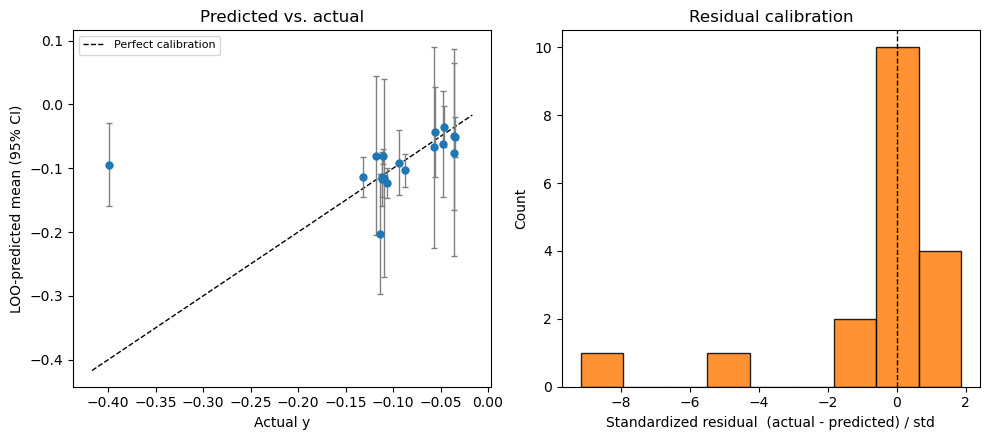

points inside their own 95% LOO interval: 16/18


In [26]:
with fitting("leave-one-out calibration"):
    pred_mean, pred_std = loo_predictions(X, y, bounds,
                                          gp_kwargs={"n_restarts_optimizer": 20})

plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")

## Iteration diagnostics

`compute_iteration_diagnostics` replays the ordered `X`/`y` to reconstruct what the acquisition value, GP hyperparameters, and domain-wide uncertainty were at each past proposal -- no persisted log involved.

It applies **one** acquisition setting to the whole history, which is normally a hazard when the history is mixed (the single recorded observation here was proposed under the old notebook's `pi`/`xi=0.01`). Replaying with `max_variance` sidesteps that: its acquisition value is just the posterior std at the point *before* it was evaluated, which is a meaningful quantity however that point was chosen. So the `acq_value` column below reads as "how uncertain was the model there beforehand" and is interpretable across the mix.

Two caveats that still apply: it assumes row order is true chronological order, and it uses the bounds passed in -- which are this week's observed bounding box, so `domain_mean_std` is the mean uncertainty over that box, not over the standard padded box. Don't compare those numbers against a week that used different bounds.

`plot_bo_diagnostics` is skipped: it hard-codes a 2D scatter panel and this is a 3D problem. The individual trend plots below are dimension-agnostic, and need a few completed iterations before any trend is readable, so they're gated.

In [ ]:
# The old `if len(new_y) == 0` guard is gone: new_y is populated above, so that
# branch was unreachable. Restore it only if this notebook is reset to a bare
# initial batch. Fitting happens first so the warnings can't split the output.
# DELIBERATE MISMATCH with this week's acquisition, and the correct choice:
# CLAUDE.md requires replaying with the settings each historical proposal was
# actually made under, and all three collected points were `max_variance`
# proposals. Once a ucb proposal is recorded the history becomes mixed and no
# single setting can reconstruct every row faithfully -- at that point the
# acq_value column stops being meaningful rather than becoming wrong silently.
with fitting("iteration-diagnostics replay (max_variance, as history was made)"):
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                            acquisition="max_variance", maximize=True)

print("Best y so far:", np.nanmax(history["y"]))
print("completed iterations beyond the initial batch:", len(new_y))

if len(new_y) >= 3:
    for plot_fn in (plot_convergence, plot_acquisition_decay,
                    plot_uncertainty_shrinkage, plot_step_distance):
        plot_fn(history)
        plt.show()
else:
    print(f"\nOnly {len(new_y)} completed iteration(s) -- need at least 3 for the trend")
    print("plots to say anything. Skipping them; the raw fields are below.")

## Raw diagnostic fields

In [28]:
print("y:", history["y"])
print("\niteration:", history["iteration"])
print("\nacq_value (NaN = initial batch; see the caveat above):", history["acq_value"])
print("\ndomain_mean_std:", history["domain_mean_std"])

y: [-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837 -0.05641777 -0.11005965 -0.03556165]

iteration: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 2. 3.]

acq_value (NaN = initial batch; see the caveat above): [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan 0.04895405 0.08871425 0.05852817]

domain_mean_std: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan 0.03936491 0.03374035 0.0254906 ]


In [29]:
# The proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X: a 6-dp copy of function 4's proposal rounded 4e-7 outside its
# own upper bound and tripped validate_bounds_consistency.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.492581-0.611593-0.617079

full precision (use for next week's new_X):
0.49258141463713434-0.6115931882759961-0.6170785019509517
